# Traffic Accident Analysis - CSE 532 Final Project

## Research Question
**In this project, we aim to investigate whether weather conditions and road characteristics influence accident severity using real-world US traffic accident data.**

---

## Part 1: Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Part 2: Download Dataset from Kaggle

In [ ]:
import kagglehub
import os

print("Downloading US Accidents dataset from Kaggle...")
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents", output_dir="../data/")
print(f"✓ Dataset downloaded to: {path}")

# find csv file
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print(f"\nCSV files found: {csv_files}")
dataset_file = os.path.join(path, csv_files[0])
print(f"Using: {csv_files[0]}")

✓ Dataset downloaded to: ../data/

CSV files found: ['US_Accidents_March23.csv']
Using: US_Accidents_March23.csv


## Part 3: Load Dataset

In [ ]:
print("Loading dataset...")
df = pd.read_csv(dataset_file, nrows=1000000)  # Load only the first 1 million rows for efficiency

print(f" * Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
print(f"  - Rows (accidents): {df.shape[0]:,}")
print(f"  - Columns (features): {df.shape[1]}")

Loading dataset...
✓ Dataset loaded successfully!

Dataset Shape: (1000000, 46)
  - Rows (accidents): 1,000,000
  - Columns (features): 46


## Part 4: Missing Values Analysis

In [ ]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_pct.values
}).sort_values('Missing_Count', ascending=False)

print("Columns with Missing Values:")
print("="*80)
missing_with_gaps = missing_df[missing_df['Missing_Count'] > 0]
if len(missing_with_gaps) > 0:
    for idx, row in missing_with_gaps.iterrows():
        pct_str = f"{row['Missing_Percentage']:.2f}%"
        print(f"{row['Column']:30s} | Count: {row['Missing_Count']:>10,d} | {pct_str:>8s}")
else:
    print("No missing values!")

print(f"\nTotal columns with missing data: {len(missing_with_gaps)}")

Columns with Missing Values:
End_Lng                        | Count:  1,000,000 |  100.00%
End_Lat                        | Count:  1,000,000 |  100.00%
Precipitation(in)              | Count:    475,316 |   47.53%
Wind_Chill(F)                  | Count:    460,589 |   46.06%
Wind_Speed(mph)                | Count:    100,398 |   10.04%
Visibility(mi)                 | Count:     18,931 |    1.89%
Weather_Condition              | Count:     18,211 |    1.82%
Humidity(%)                    | Count:     16,553 |    1.66%
Temperature(F)                 | Count:     15,298 |    1.53%
Wind_Direction                 | Count:     13,570 |    1.36%
Pressure(in)                   | Count:     12,376 |    1.24%
Weather_Timestamp              | Count:      9,927 |    0.99%
Street                         | Count:      1,712 |    0.17%
Civil_Twilight                 | Count:      1,636 |    0.16%
Astronomical_Twilight          | Count:      1,636 |    0.16%
Nautical_Twilight              | Count:  

## Part 5: Data Cleaning Strategy

We will keep most columns untouched and only fix the missing values that matter for the analysis:
- `End_Lat` and `End_Lng`: fill from the start location when missing
- `Precipitation(in)`: fill with 0 when missing
- Leave the other missing columns as-is for now


In [ ]:
print("Starting cleaning...")
df_clean = df.copy()

for end_col, start_col in [('End_Lat', 'Start_Lat'), ('End_Lng', 'Start_Lng')]:
    if end_col in df_clean.columns and start_col in df_clean.columns:
        df_clean[end_col] = df_clean[end_col].fillna(df_clean[start_col])
        print(f"Filled missing {end_col} values from {start_col}")

if 'Precipitation(in)' in df_clean.columns:
    df_clean['Precipitation(in)'] = df_clean['Precipitation(in)'].fillna(0)
    print("Filled missing Precipitation(in) values with 0")

print(f"\nOriginal shape: {df.shape}")
print(f"Cleaned shape:  {df_clean.shape}")
print("\nRemaining missing values in key cleaned columns:")
for col in ['End_Lat', 'End_Lng', 'Precipitation(in)']:
    if col in df_clean.columns:
        print(f"  {col:20s}: {df_clean[col].isnull().sum():>10,d}")

Starting cleaning...
Filled missing End_Lat values from Start_Lat
Filled missing End_Lng values from Start_Lng
Filled missing Precipitation(in) values with 0

Original shape: (1000000, 46)
Cleaned shape:  (1000000, 46)

Remaining missing values in key cleaned columns:
  End_Lat             :          0
  End_Lng             :          0
  Precipitation(in)   :          0


## Part 6: Summary Statistics We Care About

We will focus on statistics that help answer the research question across these categories:
- **Overall target variable**: Severity mean, median, std, variance
- **Weather features**: temperature, visibility, wind speed, humidity, pressure, precipitation
- **Temporal features**: hour of day, weekday, morning/night/weekend patterns
- **Road condition flags**: traffic signal, crossing, junction, stop, etc.
- **Geographic features**: state, city, and approximate accident location

In [ ]:
analysis_df = df_clean.copy()

analysis_df['Start_Time'] = pd.to_datetime(analysis_df['Start_Time'], errors='coerce')
analysis_df['Hour'] = analysis_df['Start_Time'].dt.hour
analysis_df['DayOfWeek'] = analysis_df['Start_Time'].dt.day_name()
analysis_df['IsWeekend'] = analysis_df['Start_Time'].dt.dayofweek.isin([5, 6])
analysis_df['TimeOfDay'] = pd.cut(
    analysis_df['Hour'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

print("Feature engineering complete for analysis.")
print("Available analysis columns now include Hour, DayOfWeek, IsWeekend, and TimeOfDay.")

Feature engineering complete for analysis.
Available analysis columns now include Hour, DayOfWeek, IsWeekend, and TimeOfDay.


## Part 7: Overall and Grouped Statistics

First we will compute descriptive statistics for the target variable, then break the data down by weather, time, road flags, and geography.

In [ ]:
# target statistcs
severity_stats = analysis_df['Severity'].agg(['mean', 'median', 'std', 'var', 'min', 'max'])
print("Overall Severity Statistics")
print("=" * 60)
print(severity_stats.round(3))

# weather feature summary statistics
weather_cols = [
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'Wind_Chill(F)', 'Pressure(in)', 'Precipitation(in)'
]
available_weather_cols = [col for col in weather_cols if col in analysis_df.columns]
print("\nWeather Feature Statistics")
print("=" * 60)
print(analysis_df[available_weather_cols].agg(['mean', 'median', 'std', 'var']).round(3))

# severity by weather condition
if 'Weather_Condition' in analysis_df.columns:
    weather_group_stats = analysis_df.groupby('Weather_Condition')['Severity'].agg(['count', 'mean', 'median', 'std']).sort_values('count', ascending=False)
    print("\nSeverity by Weather Condition (top 15 by count)")
    print("=" * 60)
    print(weather_group_stats.head(15).round(3))

# severity by time of day and weekend
print("\nSeverity by Time of Day")
print("=" * 60)
print(analysis_df.groupby('TimeOfDay')['Severity'].agg(['count', 'mean', 'median', 'std']).round(3))

print("\nSeverity by Weekend Flag")
print("=" * 60)
print(analysis_df.groupby('IsWeekend')['Severity'].agg(['count', 'mean', 'median', 'std']).round(3))

# road condition flags summary
road_flags = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop'
]
available_flags = [col for col in road_flags if col in analysis_df.columns]
road_summary = {}
for flag in available_flags:
    flagged = analysis_df[analysis_df[flag] == True]
    road_summary[flag] = {
        'count': int(flagged.shape[0]),
        'mean_severity': float(flagged['Severity'].mean()),
        'median_severity': float(flagged['Severity'].median())
    }

road_summary_df = pd.DataFrame(road_summary).T.sort_values('count', ascending=False)
print("\nSeverity by Road Condition Flag")
print("=" * 60)
print(road_summary_df.round(3))

# geographic summary
print("\nTop States by Accident Count")
print("=" * 60)
print(analysis_df['State'].value_counts().head(10))

Overall Severity Statistics
mean      2.212
median    2.000
std       0.488
var       0.238
min       1.000
max       4.000
Name: Severity, dtype: float64

Weather Feature Statistics
        Temperature(F)  Humidity(%)  Visibility(mi)  Wind_Speed(mph)  \
mean            61.663       64.831           9.090            7.685   
median          64.000       67.000          10.000            7.000   
std             19.014       22.821           2.688            5.425   
var            361.519      520.797           7.227           29.430   

        Wind_Chill(F)  Pressure(in)  Precipitation(in)  
mean           58.251        29.539              0.006  
median         62.000        29.860              0.000  
std            22.390         1.006              0.093  
var           501.305         1.012              0.009  

Severity by Weather Condition (top 15 by count)
                     count   mean  median    std
Weather_Condition                               
Fair               25608

## Part 8: Visualizations

We will start with the plots that best match the summary statistics:
- severity distribution
- weather feature distributions
- severity by time of day and weather
- road condition comparisons
- geographic maps of the accidents

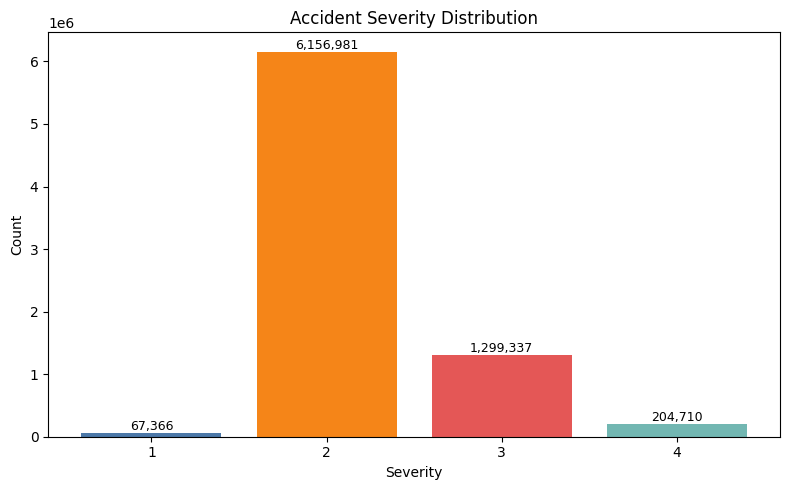

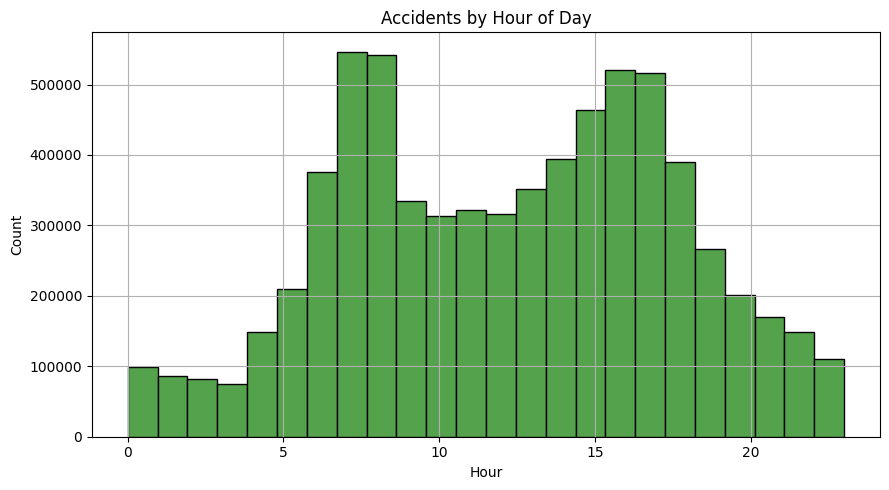

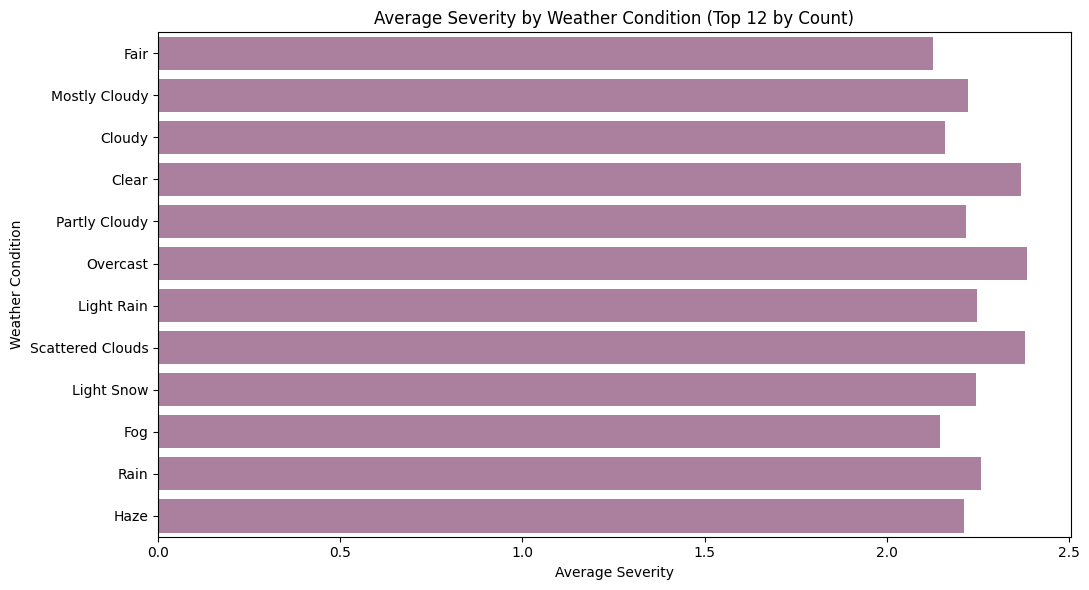

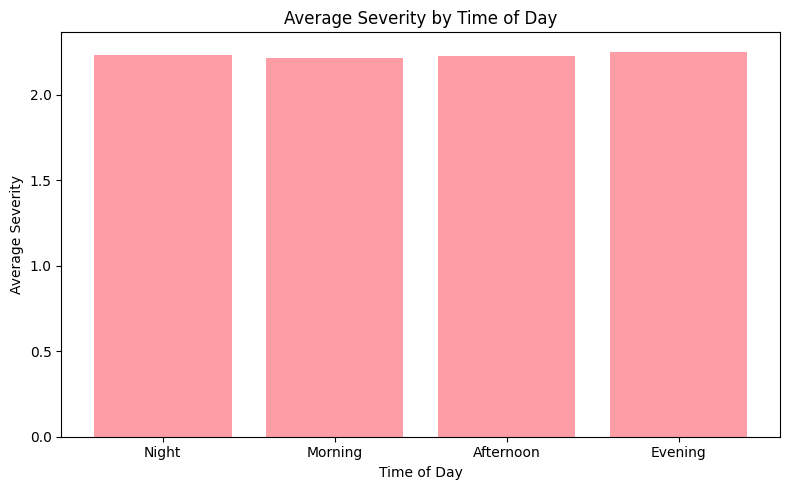

In [ ]:
# visualization libraries
import plotly.express as px

# limit mapping to subset of columns
map_cols = ['Start_Lat', 'Start_Lng', 'Severity', 'State', 'City']
map_df = analysis_df.loc[:, map_cols].dropna(subset=['Start_Lat', 'Start_Lng'])
viz_sample = map_df.sample(n=min(25000, len(map_df)), random_state=42)

# 1) severity distribution
fig, ax = plt.subplots(figsize=(8, 5))
severity_order = analysis_df['Severity'].value_counts().sort_index()
ax.bar(severity_order.index.astype(str), severity_order.values, color=['#4c78a8', '#f58518', '#e45756', '#72b7b2'])
ax.set_title('Accident Severity Distribution')
ax.set_xlabel('Severity')
ax.set_ylabel('Count')
for i, value in enumerate(severity_order.values):
    ax.text(i, value, f'{value:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# 2) hour of day histogram
fig, ax = plt.subplots(figsize=(9, 5))
analysis_df['Hour'].dropna().hist(bins=24, ax=ax, color='#54a24b', edgecolor='black')
ax.set_title('Accidents by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# 3) weather condition vs severity (top conditions by count)
if 'Weather_Condition' in analysis_df.columns:
    weather_plot = (
        analysis_df.groupby('Weather_Condition')
        .agg(count=('Severity', 'size'), mean_severity=('Severity', 'mean'))
        .sort_values('count', ascending=False)
        .head(12)
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.barplot(data=weather_plot, x='mean_severity', y='Weather_Condition', ax=ax, color='#b279a2')
    ax.set_title('Average Severity by Weather Condition (Top 12 by Count)')
    ax.set_xlabel('Average Severity')
    ax.set_ylabel('Weather Condition')
    plt.tight_layout()
    plt.show()

# 4) time of day comparison
fig, ax = plt.subplots(figsize=(8, 5))
time_plot = analysis_df.groupby('TimeOfDay')['Severity'].mean().reindex(['Night', 'Morning', 'Afternoon', 'Evening'])
ax.bar(time_plot.index.astype(str), time_plot.values, color='#ff9da6')
ax.set_title('Average Severity by Time of Day')
ax.set_xlabel('Time of Day')
ax.set_ylabel('Average Severity')
plt.tight_layout()
plt.show()

# 5) map of accidents across the US using a sampled subset
us_map = px.scatter_mapbox(
    viz_sample,
    lat='Start_Lat',
    lon='Start_Lng',
    color='Severity',
    color_continuous_scale='Turbo',
    zoom=3,
    height=650,
    title='US Traffic Accidents Map (Sampled Points)',
    mapbox_style='open-street-map',
    hover_data=['State', 'City', 'Severity']
)
us_map.update_layout(margin={'r':0, 't':50, 'l':0, 'b':0})
us_map.show()

# 6) Indiana + Kentucky closer view
in_ky = viz_sample[viz_sample['State'].isin(['IN', 'KY'])].copy()
if not in_ky.empty:
    in_ky_map = px.scatter_mapbox(
        in_ky,
        lat='Start_Lat',
        lon='Start_Lng',
        color='Severity',
        color_continuous_scale='Turbo',
        zoom=5.5,
        center={'lat': 38.9, 'lon': -85.3},
        height=650,
        title='Traffic Accidents in Indiana and Kentucky (Sampled Points)',
        mapbox_style='open-street-map',
        hover_data=['State', 'City', 'Severity']
    )
    in_ky_map.update_layout(margin={'r':0, 't':50, 'l':0, 'b':0})
    in_ky_map.show()
else:
    print('No Indiana/Kentucky records were found in the sample.')

## Part 11: Target Variable - Accident Severity

Let's examine our target variable:

In [ ]:
print("Accident Severity Distribution:")
print("="*80)
severity_counts = df['Severity'].value_counts().sort_index()
for severity, count in severity_counts.items():
    pct = (count / len(df)) * 100
    bar = '█' * int(pct / 2)
    print(f"Severity {severity}: {count:>10,d} ({pct:>6.2f}%) {bar}")

print(f"\nMissing Severity values: {df['Severity'].isnull().sum()}")
print(f"Unique severity levels: {sorted(df['Severity'].unique())}")

Accident Severity Distribution:
Severity 1:     67,366 (  0.87%) 
Severity 2:  6,156,981 ( 79.67%) ███████████████████████████████████████
Severity 3:  1,299,337 ( 16.81%) ████████
Severity 4:    204,710 (  2.65%) █

Missing Severity values: 0
Unique severity levels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
